<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/04_transfer_learning_ika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. setup — preuzimanje dataset-a (Kaggle)

In [1]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install -U kaggle -q
!kaggle datasets download -d balabaskar/tom-and-jerry-image-classification
!unzip -q tom-and-jerry-image-classification.zip -d data/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 10.6 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/balabaskar/tom-and-jerry-image-classification
License(s): CC0-1.0
100% 435M/435M [00:21<00:00, 20.9MB/s]



In [2]:
!ls data/

challenges.csv	ground_truth.csv  tom_and_jerry


### 2. setup - loniranje GitHub repo-a (za data_split.csv i push)

In [3]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
username = "ilinkabibic"
repo_name = "Tom-and-Jerry-Character-Classification"

!git clone https://{token}@github.com/{username}/{repo_name}.git
%cd {repo_name}
!git config user.email "bibic.ilinka@gmail.com"
!git config user.name "Ika"
!ls

Cloning into 'Tom-and-Jerry-Character-Classification'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 51 (delta 21), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 30.35 MiB | 17.45 MiB/s, done.
Resolving deltas: 100% (21/21), done.
/content/Tom-and-Jerry-Character-Classification
data_split.csv	features_hog_color.npy	notebooks


### Učitavanje podele podataka (train/val/test)bold text

In [4]:
import pandas as pd
split_df = pd.read_csv('data_split.csv')  # učitava data_split.csv u pandas DataFrame split_df
print(split_df['split'].value_counts())   # ispisujemo broj slika po train/val/test plus
print(split_df.head())                    # prvih par redova da vidimo kako izgledaju kolone.

split
train    3778
val       850
test      850
Name: count, dtype: int64
     filename  tom  jerry    class  split
0  frame0.jpg    0      0  neither  train
1  frame1.jpg    0      0  neither  train
2  frame2.jpg    0      0  neither  train
3  frame3.jpg    0      0  neither  train
4  frame4.jpg    0      0  neither  train


In [5]:
!ls ../data/tom_and_jerry

tom_and_jerry


In [6]:
!ls ../data/tom_and_jerry/tom_and_jerry

jerry  tom  tom_jerry_0  tom_jerry_1


In [7]:
print(split_df['class'].unique())

['neither' 'jerry' 'tom' 'both']


### Povezivanje slika sa podelom (pravljenje pune putanje)

In [8]:
# Mapiranje naziva klase (iz CSV-a) na naziv foldera sa slikama
class_to_folder = {
    'neither': 'tom_jerry_0',
    'both': 'tom_jerry_1',
    'jerry': 'jerry',
    'tom': 'tom'
}

data_dir = '../data/tom_and_jerry/tom_and_jerry'

# Za svaki red napravi punu putanju do slike: folder klase + ime fajla
split_df['filepath'] = split_df.apply(
    lambda row: f"{data_dir}/{class_to_folder[row['class']]}/{row['filename']}", axis=1
)

import os
# Provera: da li prva i poslednja putanja stvarno postoje na disku
print(split_df['filepath'].iloc[0], os.path.exists(split_df['filepath'].iloc[0]))
print(split_df['filepath'].iloc[-1], os.path.exists(split_df['filepath'].iloc[-1]))

../data/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame0.jpg True
../data/tom_and_jerry/tom_and_jerry/tom_jerry_0/frame5477.jpg True


### PyTorch Dataset — enkodiranje klasa i učitavanje slika

In [9]:
import torch
from torch.utils.data import Dataset
from PIL import Image

# Enkodiranje klasa u brojeve (mreža radi samo sa brojevima, ne sa tekstom)
class_to_idx = {'tom': 0, 'jerry': 1, 'both': 2, 'neither': 3}
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Dataset klasa: zna kako da učita JEDNU sliku po rednom broju
class TomJerryDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)  # ukupan broj slika u ovom delu (train/val/test)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')  # učitaj sliku
        label = class_to_idx[row['class']]                   # klasa -> broj
        if self.transform:
            image = self.transform(image)                    # primeni transformacije
        return image, label

print("Dataset klasa definisana, klase:", class_to_idx)

Dataset klasa definisana, klase: {'tom': 0, 'jerry': 1, 'both': 2, 'neither': 3}


### Transformacije i DataLoader-i (train/val/test)

Slike se prilagođavaju formatu na kom je ResNet18 pretreniran na ImageNet-u: sve se svode na 224×224 piksela i normalizuju istim mean/std vrednostima kao ImageNet, da bi pretrenirane težine imale smisla na našim podacima.

Podaci se dele na train/val/test po već postojećoj `split` koloni, pa se prave PyTorch `Dataset` i `DataLoader` objekti za svaki deo — `DataLoader` servira slike u paketima (batch-evima) od 32, i to omogućava paralelno učitavanje i mešanje redosleda (samo za train, jer val/test ne smeju da se mešaju niti utiču na učenje).

In [10]:
from torchvision import transforms
from torch.utils.data import DataLoader

# Transformacije: uskladi sliku sa onim na čemu je ResNet18 pretreniran (ImageNet)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Podela na train/val/test (koristimo istu 'split' kolonu)
train_df = split_df[split_df['split'] == 'train']
val_df   = split_df[split_df['split'] == 'val']
test_df  = split_df[split_df['split'] == 'test']

train_ds = TomJerryDataset(train_df, transform=transform)
val_ds   = TomJerryDataset(val_df, transform=transform)
test_ds  = TomJerryDataset(test_df, transform=transform)

# DataLoader-i: serviraju slike u paketima od 32 (batch_size), train se meša (shuffle)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(len(train_ds), len(val_ds), len(test_ds))

# Provera: uzmi jedan batch i pogledaj oblik tenzora
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

3778 850 850
torch.Size([32, 3, 224, 224]) torch.Size([32])


### Model — ResNet18 (transfer learning)

Koristi se ResNet18 pretreniran na ImageNet-u (14 miliona slika, 1000 klasa) — mreža već zna da prepoznaje opšte vizuelne osobine (ivice, oblike, teksture), pa joj ne treba trening od nule. Poslednji sloj (`fc`) se zamenjuje novim, sa 4 izlaza umesto 1000, prilagođenim našem zadatku (tom / jerry / both / neither). Ostatak mreže zadržava naučene težine i dalje se fino podešava (fine-tuning) tokom treninga.

In [11]:
import torch.nn as nn
from torchvision import models

# GPU ako je dostupan (T4 u Colab-u), inače CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# Pretrenirani ResNet18 (ImageNet težine)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Zameni poslednji sloj: 1000 ImageNet klasa -> 4 naše klase
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 4)

model = model.to(device)
print(model.fc)

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s]


Linear(in_features=512, out_features=4, bias=True)


# Eksperiment 1 — prvi pokušaj fine-tuning-a (lr=0.001)

Ovo je prvi pokušaj treniranja transfer learning modela — koristimo podrazumevani (standardni) learning rate od 0.001, bez ikakvih dodatnih podešavanja (nema class weights, nema checkpointing-a u ovoj prvoj verziji). Cilj je da vidimo kako se pretrenirani ResNet18 ponaša na ovom zadatku "iz kutije", pre nego što bilo šta fino podešavamo.

### Loss funkcija i optimizator

In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()               # mjeri koliko model griješi
optimizer = optim.Adam(model.parameters(), lr=0.001)  # ažurira težine mreže

print("Loss i optimizer definisani")

Loss i optimizer definisani


In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # --- trening faza ---
        model.train()  # rezim treninga (bitno za slojeve kao Batch Norm)
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()          # obriši gradijente iz prethodnog batch-a
            outputs = model(images)        # forward pass — predikcije mreže
            loss = criterion(outputs, labels)  # koliko mreža griješi (CrossEntropyLoss)
            loss.backward()                # izračunaj gradijente (backpropagation)
            optimizer.step()               # ažuriraj težine mreže

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)   # klasa sa najvećom verovatnoćom
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # --- validacija ---
        model.eval()  # režim evaluacije, ne treniramo
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # ne računamo gradijente (brže, štedi memoriju)
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    return history

print("Funkcija definisana")

Funkcija definisana


In [14]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

Epoch 1/5 | Train loss: 0.5613, acc: 0.7935 | Val loss: 0.5552, acc: 0.7988
Epoch 2/5 | Train loss: 0.3225, acc: 0.8936 | Val loss: 0.6622, acc: 0.7565
Epoch 3/5 | Train loss: 0.2780, acc: 0.9121 | Val loss: 0.7441, acc: 0.7835
Epoch 4/5 | Train loss: 0.2639, acc: 0.9140 | Val loss: 0.6839, acc: 0.8471
Epoch 5/5 | Train loss: 0.1590, acc: 0.9473 | Val loss: 0.4216, acc: 0.8565


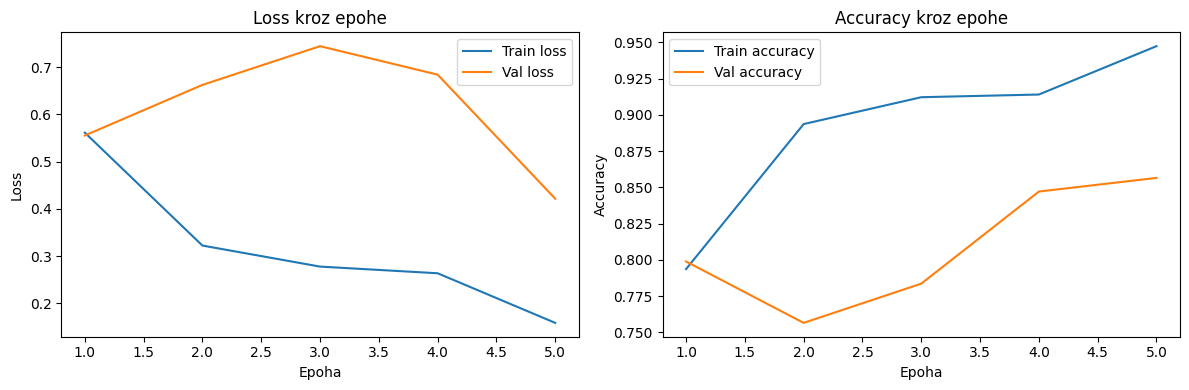

In [15]:
import matplotlib.pyplot as plt

# Broj epoha (x-osa) — koliko god ih ima u history
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Levi graf: loss (train vs val)
axes[0].plot(epochs, history['train_loss'], label='Train loss')
axes[0].plot(epochs, history['val_loss'], label='Val loss')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss kroz epohe')
axes[0].legend()

# Desni graf: accuracy (train vs val)
axes[1].plot(epochs, history['train_acc'], label='Train accuracy')
axes[1].plot(epochs, history['val_acc'], label='Val accuracy')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy kroz epohe')
axes[1].legend()

plt.tight_layout()
plt.show()

### Zapažanje

Kroz više pokretanja ovog koda, val accuracy dosljedno osciluje mnogo više nego train accuracy — često sa naglim padovima u ranim epohama, i val loss koji ne prati train loss na dole nego raste. To ukazuje da je lr=0.001 prevelik korak za fine-tuning već pretreniranog modela — u Eksperimentu 2 probamo manji learning rate (0.0001) i dodajemo class weights.

# Eksperiment 2 — lr=0.0001, checkpointing po macro-F1

Na osnovu problema uočenih u Eksperimentu 1 (nestabilan val loss, previsok learning rate), smanjujemo learning rate na 0.0001 za stabilniji fine-tuning, i menjamo checkpointing da bira najbolju epohu po macro-F1 umesto po accuracy — macro-F1 bolje odražava performanse modela kad su klase neizbalansirane.

In [16]:
from sklearn.metrics import f1_score
import copy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_f1 = -1.0                                    # najbolji macro-F1 do sad
    best_model_weights = copy.deepcopy(model.state_dict())  # "snimak" trenutnih težina

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        val_y_true, val_y_pred = [], []  # čuvamo SVE predikcije, treba nam za f1_score

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
                val_y_true.extend(labels.cpu().tolist())
                val_y_pred.extend(predicted.cpu().tolist())

        val_loss, val_acc = val_running_loss / val_total, val_correct / val_total
        val_f1 = f1_score(val_y_true, val_y_pred, average='macro')  # macro-F1 za ovu epohu

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        # checkpointing: sačuvaj težine SAMO ako je ovo najbolji macro-F1 do sad
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}/{num_epochs} | Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, acc: {val_acc:.4f}, macroF1: {val_f1:.4f}")

    model.load_state_dict(best_model_weights)  # vrati NAJBOLJI model, ne poslednji
    print(f"\nNajbolji val macro-F1: {best_val_f1:.4f} — vraćene su te težine u model.")
    return model, history

In [17]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Model i optimizer resetovani")

Model i optimizer resetovani


In [18]:
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

Epoch 1/5 | Train loss: 0.4915, acc: 0.8195 | Val loss: 0.4500, acc: 0.8376, macroF1: 0.8251
Epoch 2/5 | Train loss: 0.0993, acc: 0.9711 | Val loss: 0.5319, acc: 0.8259, macroF1: 0.8099
Epoch 3/5 | Train loss: 0.0709, acc: 0.9791 | Val loss: 0.5387, acc: 0.7988, macroF1: 0.7808
Epoch 4/5 | Train loss: 0.0422, acc: 0.9897 | Val loss: 0.5646, acc: 0.8294, macroF1: 0.8132
Epoch 5/5 | Train loss: 0.0227, acc: 0.9944 | Val loss: 0.5074, acc: 0.8494, macroF1: 0.8396

Najbolji val macro-F1: 0.8396 — vraćene su te težine u model.


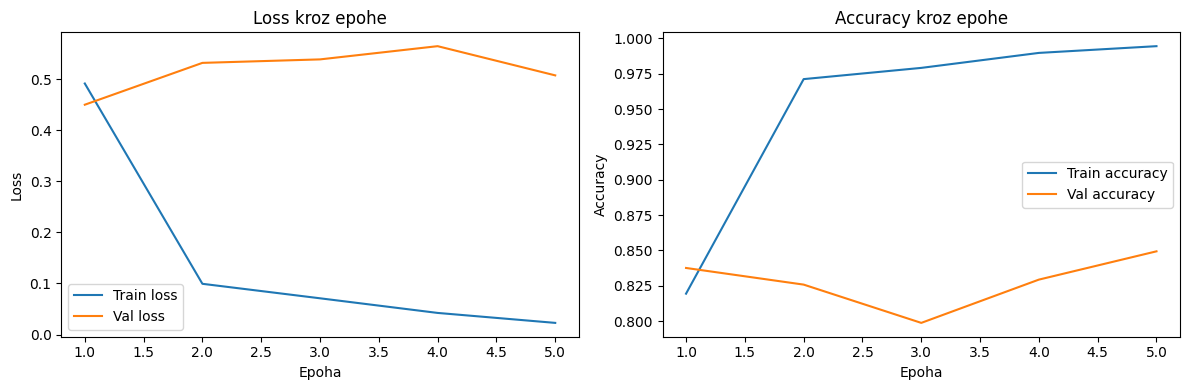

In [19]:
import matplotlib.pyplot as plt

# Broj epoha (x-osa) — koliko god ih ima u history
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Levi graf: loss (train vs val)
axes[0].plot(epochs, history['train_loss'], label='Train loss')
axes[0].plot(epochs, history['val_loss'], label='Val loss')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss kroz epohe')
axes[0].legend()

# Desni graf: accuracy (train vs val)
axes[1].plot(epochs, history['train_acc'], label='Train accuracy')
axes[1].plot(epochs, history['val_acc'], label='Val accuracy')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy kroz epohe')
axes[1].legend()

plt.tight_layout()
plt.show()

### Zapažanje

U odnosu na Eksperiment 1, snižavanje learning rate-a na 0.0001 je znatno stabilizovalo trening — val performanse više ne skaču haotično. Međutim, neizbalansiranost klasa (klasa "both" ima najmanje primera) još uvek nije direktno rešena u loss funkciji — u Eksperimentu 3 dodajemo class weights da model posveti više pažnje retkim klasama.

# Eksperiment 3 — lr=0.0001 + class weights, checkpointing po macro-F1

Isti hiperparametri kao Eksperiment 2 (lr=0.0001, class weights), ali checkpointing sad bira najbolju epohu po macro-F1 umesto po accuracy.

In [20]:
import numpy as np

# class weights na osnovu broja slika po klasi u train setu
counts = train_df['class'].map(class_to_idx).value_counts().sort_index()
weights = counts.sum() / (len(class_to_idx) * counts)
class_w = torch.tensor(weights.values, dtype=torch.float32, device=device)
print("Broj slika po klasi (train):", counts.values)
print("Težine klasa:", class_w)

# resetuj model + optimizer + criterion sa weight-ovima
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss(weight=class_w)

print("Model, optimizer i criterion (sa class weights) resetovani")

Broj slika po klasi (train): [1323  841  534 1080]
Težine klasa: tensor([0.7139, 1.1231, 1.7687, 0.8745], device='cuda:0')
Model, optimizer i criterion (sa class weights) resetovani


In [21]:
model, history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5)

Epoch 1/5 | Train loss: 0.5352, acc: 0.7978 | Val loss: 0.5570, acc: 0.7635, macroF1: 0.7511
Epoch 2/5 | Train loss: 0.1136, acc: 0.9653 | Val loss: 0.7032, acc: 0.7612, macroF1: 0.7359
Epoch 3/5 | Train loss: 0.0556, acc: 0.9868 | Val loss: 0.5881, acc: 0.8224, macroF1: 0.8090
Epoch 4/5 | Train loss: 0.0339, acc: 0.9915 | Val loss: 0.6816, acc: 0.7694, macroF1: 0.7547
Epoch 5/5 | Train loss: 0.0387, acc: 0.9899 | Val loss: 0.6754, acc: 0.8188, macroF1: 0.8037

Najbolji val macro-F1: 0.8090 — vraćene su te težine u model.


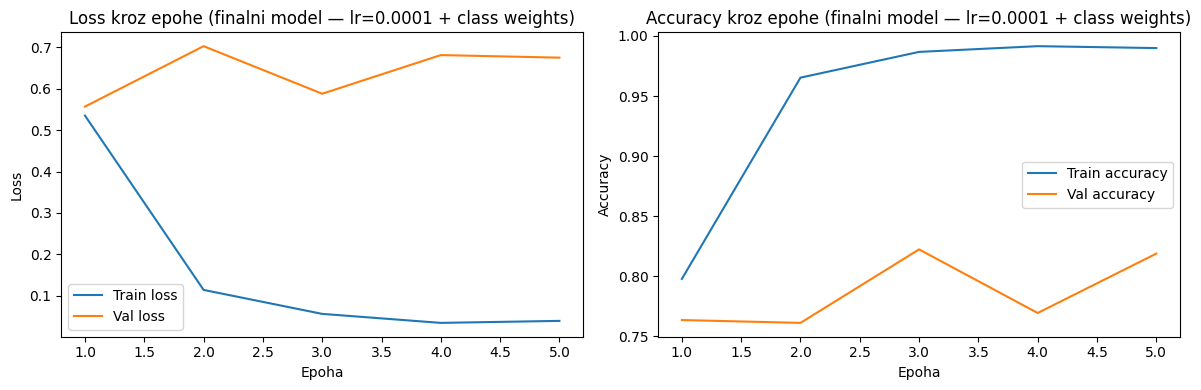

In [22]:
epochs = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], label='Train loss')
axes[0].plot(epochs, history['val_loss'], label='Val loss')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss kroz epohe (finalni model — lr=0.0001 + class weights)')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train accuracy')
axes[1].plot(epochs, history['val_acc'], label='Val accuracy')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy kroz epohe (finalni model — lr=0.0001 + class weights)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Evaluacija — macro-F1 po klasi (val)



In [23]:
from sklearn.metrics import classification_report

model.eval()  # režim evaluacije
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        pred = model(images).argmax(1).cpu()  # klasa sa najvećom verovatnoćom
        y_pred.extend(pred.tolist())
        y_true.extend(labels.tolist())

# brojeve klasa vratimo u imena, radi čitljivosti izveštaja
y_true_ime = [idx_to_class[i] for i in y_true]
y_pred_ime = [idx_to_class[i] for i in y_pred]

class_names = ['tom', 'jerry', 'both', 'neither']

# precision/recall/F1 po klasi + macro-F1 (red "macro avg")
print(classification_report(y_true_ime, y_pred_ime, labels=class_names))

              precision    recall  f1-score   support

         tom       0.80      0.91      0.85       314
       jerry       0.91      0.83      0.87       203
        both       0.77      0.71      0.74       115
     neither       0.82      0.74      0.78       218

    accuracy                           0.82       850
   macro avg       0.82      0.80      0.81       850
weighted avg       0.83      0.82      0.82       850



### Matrica konfuzije (val)

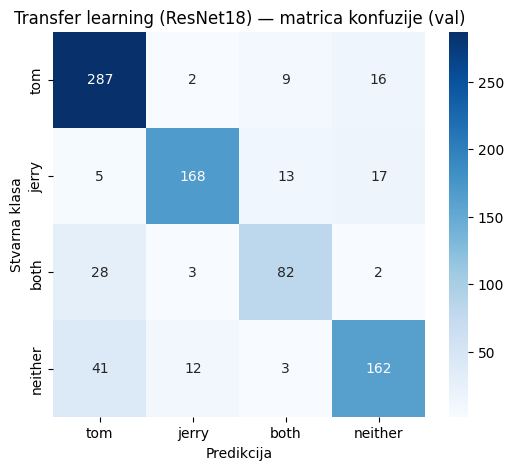

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# matrica konfuzije — gde tačno model greši, koje klase meša
cm = confusion_matrix(y_true_ime, y_pred_ime, labels=class_names)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predikcija')
plt.ylabel('Stvarna klasa')
plt.title('Transfer learning (ResNet18) — matrica konfuzije (val)')
plt.show()

# Finalna evaluacija — TEST skup

Ovo je jedina evaluacija na test skupu u celom notebook-u — koristi se GOTOV, već istreniran model (iz Eksperimenta 3, sa class weights), bez ikakvog daljeg treniranja ili podešavanja. Ista funkcija (`evaluate_on_test`) se koristi i kod klasičnih i kod dubokih modela, za fer poređenje u finalnoj tabeli.

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import seaborn as sns

# Deljena funkcija za evaluaciju — ista se koristi u SVA 4 notebook-a (02, 03, 04, 05)
def evaluate_on_test(y_true, y_pred, model_name, class_names):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"=== {model_name} — TEST rezultati ===")
    print(f"Accuracy: {acc:.4f}   Macro-F1: {macro_f1:.4f}\n")
    print(classification_report(y_true, y_pred, labels=class_names))

    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predikcija'); plt.ylabel('Stvarna klasa')
    plt.title(f'{model_name} — matrica konfuzije (TEST)')
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'macro_f1': macro_f1}

=== Transfer learning (ResNet18) — TEST rezultati ===
Accuracy: 0.8424   Macro-F1: 0.8202

              precision    recall  f1-score   support

         tom       0.83      0.89      0.86       293
       jerry       0.92      0.83      0.87       196
        both       0.69      0.62      0.65       131
     neither       0.88      0.92      0.90       230

    accuracy                           0.84       850
   macro avg       0.83      0.81      0.82       850
weighted avg       0.84      0.84      0.84       850



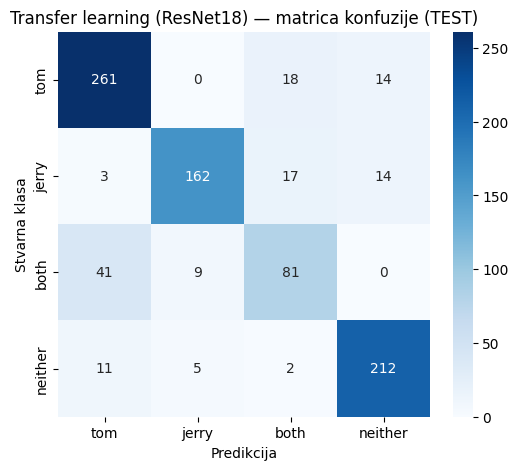

In [26]:
model.eval()  # finalni, već istrenirani model (iz Eksperimenta 3)
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:  # prvi i jedini put koristimo test_loader
        images = images.to(device)
        pred = model(images).argmax(1).cpu()
        y_pred.extend(pred.tolist())
        y_true.extend(labels.tolist())

y_true_ime = [idx_to_class[i] for i in y_true]
y_pred_ime = [idx_to_class[i] for i in y_pred]
class_names = ['tom', 'jerry', 'both', 'neither']

rezultat_transfer = evaluate_on_test(y_true_ime, y_pred_ime, "Transfer learning (ResNet18)", class_names)